# 🤖 Phase 2 — Model Training, Evaluation & Saving
**Project:** Worker Productivity Dashboard

### What this notebook does
| Sub-phase | Goal |
|-----------|------|
| 2A | Train/test split |
| 2B | Baseline models — Linear Regression, Decision Tree |
| 2C | Advanced models — Random Forest, XGBoost |
| 2D | Hyperparameter tuning on the best model |
| 2E | Feature importance + explainability chart |
| 2F | Save final model and scaler ← **critical milestone** |

> Run cells top-to-bottom. The final cell writes `productivity_model.pkl` to `/model/`.

---
## Setup — Imports & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing      import StandardScaler
from sklearn.linear_model       import LinearRegression
from sklearn.tree               import DecisionTreeRegressor
from sklearn.ensemble           import RandomForestRegressor
from sklearn.metrics            import mean_squared_error, mean_absolute_error, r2_score
from xgboost                    import XGBRegressor

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

CLEANED_PATH = '../data/cleaned/garment_clean.csv'
MODEL_DIR    = '../model'

df           = pd.read_csv(CLEANED_PATH)
feature_cols = joblib.load(os.path.join(MODEL_DIR, 'feature_columns.pkl'))
TARGET       = joblib.load(os.path.join(MODEL_DIR, 'target_column.pkl'))

print(f'✅ Cleaned data loaded : {df.shape}')
print(f'   Target              : {TARGET}')
print(f'   Features            : {len(feature_cols)}')

✅ Cleaned data loaded : (1197, 23)
   Target              : actual_productivity
   Features            : 22


---
## Helper — Evaluation Function

One function that computes RMSE, MAE, and R² so we don't repeat ourselves across every model.

In [2]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:<30} RMSE: {rmse:.4f}   MAE: {mae:.4f}   R²: {r2:.4f}')
    return {'Model': name, 'RMSE': round(rmse,4),
            'MAE': round(mae,4), 'R2': round(r2,4)}

results = []   # collect all model scores here
print('✅ evaluate() ready')

✅ evaluate() ready


---
## 2A — Train / Test Split

80 / 20 split, stratified by binned productivity to ensure both splits see the full range of the target. `random_state=42` for reproducibility.

In [3]:
X = df[feature_cols]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit scaler on TRAIN only, then apply to both splits
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'  Train set : {X_train.shape[0]} rows')
print(f'  Test  set : {X_test.shape[0]} rows')
print(f'  Features  : {X_train.shape[1]}')
print(f'\n  Train target — mean: {y_train.mean():.4f}  std: {y_train.std():.4f}')
print(f'  Test  target — mean: {y_test.mean():.4f}  std: {y_test.std():.4f}')
print('\n✅ Split and scaler ready')

  Train set : 957 rows
  Test  set : 240 rows
  Features  : 22

  Train target — mean: 0.7317  std: 0.1759
  Test  target — mean: 0.7453  std: 0.1629

✅ Split and scaler ready


---
## 2B — Baseline Models

These set the performance floor. If our advanced models can't beat these, something is wrong.

- **Linear Regression** — assumes a straight-line relationship between features and target
- **Decision Tree** — non-linear but prone to overfitting without constraints

In [4]:
print('BASELINE MODELS')
print('=' * 65)

# --- Linear Regression (needs scaled input) ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
results.append(evaluate('Linear Regression', y_test, lr.predict(X_test_scaled)))

# --- Decision Tree ---
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
results.append(evaluate('Decision Tree (depth=6)', y_test, dt.predict(X_test)))

print()
print('📌 These are your floor benchmarks — advanced models must beat these.')

BASELINE MODELS
  Linear Regression              RMSE: 0.1329   MAE: 0.0949   R²: 0.3313
  Decision Tree (depth=6)        RMSE: 0.1316   MAE: 0.0847   R²: 0.3442

📌 These are your floor benchmarks — advanced models must beat these.


---
## 2C — Advanced Models

Both use default hyperparameters here — tuning comes in 2D.

- **Random Forest** — ensemble of decision trees, averages out overfitting
- **XGBoost** — gradient boosting; typically the strongest performer on tabular data

In [5]:
print('ADVANCED MODELS')
print('=' * 65)

# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate('Random Forest (default)', y_test, rf.predict(X_test)))

# --- XGBoost ---
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train)
results.append(evaluate('XGBoost (default)', y_test, xgb.predict(X_test)))

print()

# --- Comparison table ---
results_df = pd.DataFrame(results).sort_values('RMSE')
print('FULL MODEL COMPARISON (sorted by RMSE ↑ = better):')
print(results_df.to_string(index=False))

ADVANCED MODELS
  Random Forest (default)        RMSE: 0.1129   MAE: 0.0695   R²: 0.5178
  XGBoost (default)              RMSE: 0.1212   MAE: 0.0733   R²: 0.4442

FULL MODEL COMPARISON (sorted by RMSE ↑ = better):
                  Model   RMSE    MAE     R2
Random Forest (default) 0.1129 0.0695 0.5178
      XGBoost (default) 0.1212 0.0733 0.4442
Decision Tree (depth=6) 0.1316 0.0847 0.3442
      Linear Regression 0.1329 0.0949 0.3313


---
## 2D — Cross-Validation & Hyperparameter Tuning

We run 5-fold cross-validation on XGBoost first to confirm it generalises, then use `RandomizedSearchCV` to find better hyperparameters.

> `RandomizedSearchCV` samples a random subset of the parameter grid — much faster than `GridSearchCV` with 90%+ of the benefit.

In [6]:
print('5-FOLD CROSS-VALIDATION — XGBoost (default params)')
print('=' * 55)
cv_scores = cross_val_score(
    XGBRegressor(n_estimators=200, learning_rate=0.1,
                 max_depth=5, random_state=42, verbosity=0),
    X, y, cv=5, scoring='r2', n_jobs=-1
)
print(f'  R² per fold : {[round(s,4) for s in cv_scores]}')
print(f'  Mean R²     : {cv_scores.mean():.4f}')
print(f'  Std  R²     : {cv_scores.std():.4f}')
print()
if cv_scores.std() < 0.05:
    print('✅ Low variance across folds — model generalises well')
else:
    print('⚠️  High variance across folds — model may be unstable')

5-FOLD CROSS-VALIDATION — XGBoost (default params)
  R² per fold : [np.float64(0.3127), np.float64(0.2891), np.float64(0.4342), np.float64(0.3325), np.float64(0.2471)]
  Mean R²     : 0.3231
  Std  R²     : 0.0624

⚠️  High variance across folds — model may be unstable


In [7]:
print('RANDOMIZED SEARCH — XGBoost Hyperparameter Tuning')
print('=' * 55)
print('This may take 1–2 minutes...')

param_dist = {
    'n_estimators'  : [100, 200, 300, 500],
    'max_depth'     : [3, 4, 5, 6, 7],
    'learning_rate' : [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample'     : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_distributions=param_dist,
    n_iter=40,
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

print(f'\n  Best params : {search.best_params_}')
print(f'  Best CV R²  : {search.best_score_:.4f}')

# Evaluate tuned model on test set
best_xgb = search.best_estimator_
tuned_result = evaluate('XGBoost (tuned)', y_test, best_xgb.predict(X_test))
results.append(tuned_result)
print('\n✅ Tuning complete')

RANDOMIZED SEARCH — XGBoost Hyperparameter Tuning
This may take 1–2 minutes...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

  Best params : {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
  Best CV R²  : 0.5003
  XGBoost (tuned)                RMSE: 0.1145   MAE: 0.0721   R²: 0.5040

✅ Tuning complete


---
## 2E — Feature Importance & Explainability

We extract `feature_importances_` from the tuned XGBoost model and plot them. This same chart drives the 'Why' breakdown panel in the Streamlit dashboard.

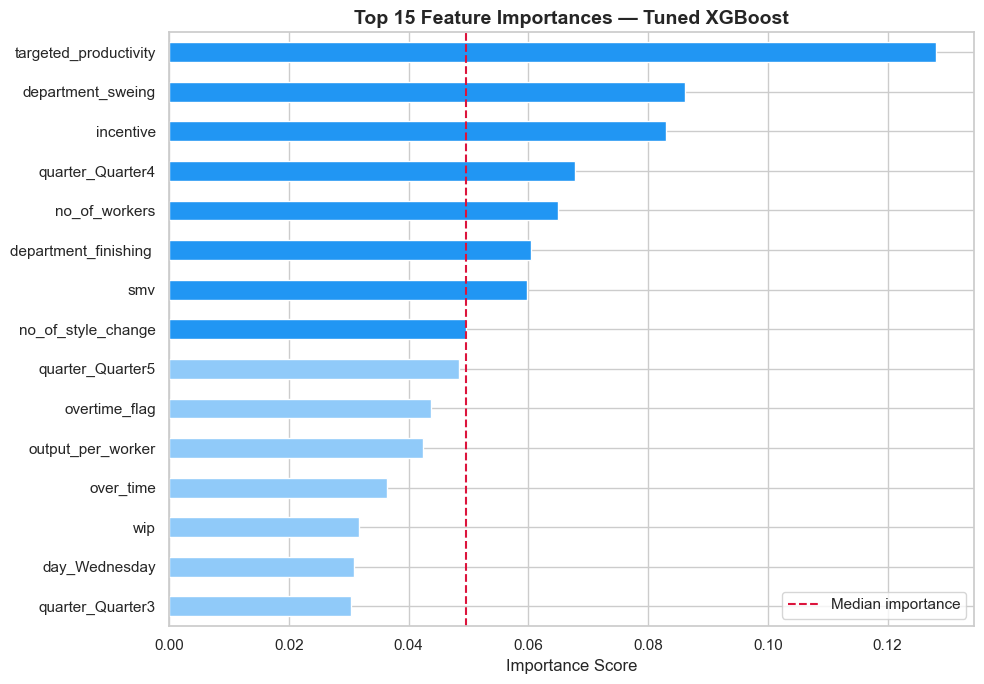

📁 Saved → data/cleaned/feature_importance.png

Full ranked importances:
targeted_productivity    0.1280
department_sweing        0.0862
incentive                0.0829
quarter_Quarter4         0.0677
no_of_workers            0.0650
department_finishing     0.0605
smv                      0.0597
no_of_style_change       0.0495
quarter_Quarter5         0.0484
overtime_flag            0.0437
output_per_worker        0.0425
over_time                0.0363
wip                      0.0317
day_Wednesday            0.0309
quarter_Quarter3         0.0304
day_Tuesday              0.0292
day_Thursday             0.0288
quarter_Quarter2         0.0271
day_Sunday               0.0265
day_Saturday             0.0248
idle_men                 0.0000
idle_time                0.0000


In [8]:
importances = pd.Series(
    best_xgb.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

# Filter to top 15 for readability
top_n = 15
top_importances = importances.tail(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ['#2196F3' if v >= top_importances.median() else '#90CAF9'
           for v in top_importances.values]
top_importances.plot(
    kind='barh', ax=ax, color=colors, edgecolor='white'
)
ax.set_title(
    f'Top {top_n} Feature Importances — Tuned XGBoost',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
ax.axvline(top_importances.median(), color='crimson',
           linestyle='--', linewidth=1.5, label='Median importance')
ax.legend()
plt.tight_layout()
plt.savefig('../data/cleaned/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('📁 Saved → data/cleaned/feature_importance.png')

print('\nFull ranked importances:')
print(importances.sort_values(ascending=False).round(4).to_string())

---
## Final Model Comparison

All four models side by side. The tuned XGBoost should lead on R².

FINAL MODEL COMPARISON
                     Model    RMSE     MAE      R2
1  Random Forest (default)  0.1129  0.0695  0.5178
2          XGBoost (tuned)  0.1145  0.0721  0.5040
3        XGBoost (default)  0.1212  0.0733  0.4442
4  Decision Tree (depth=6)  0.1316  0.0847  0.3442
5        Linear Regression  0.1329  0.0949  0.3313

🏆 Best model: Random Forest (default)


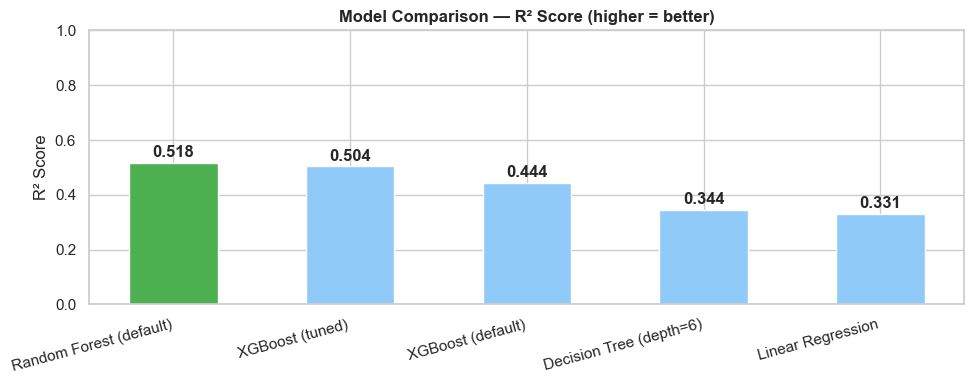

📁 Saved → data/cleaned/model_comparison.png


In [9]:
final_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
final_df.index += 1

print('FINAL MODEL COMPARISON')
print('=' * 65)
print(final_df.to_string())

best_model_name = final_df.iloc[0]['Model']
print(f'\n🏆 Best model: {best_model_name}')

# Quick visualisation
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(final_df))
bars = ax.bar(x, final_df['R2'], color=['#4CAF50' if i == 0 else '#90CAF9'
                                         for i in range(len(final_df))],
              edgecolor='white', width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(final_df['Model'], rotation=15, ha='right')
ax.set_ylabel('R² Score')
ax.set_title('Model Comparison — R² Score (higher = better)', fontweight='bold')
ax.set_ylim(0, 1)
for bar, val in zip(bars, final_df['R2']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/cleaned/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('📁 Saved → data/cleaned/model_comparison.png')

---
## 2F — Save Final Model & Scaler ✅ CRITICAL MILESTONE

Three files saved to `/model/`:

| File | Contents |
|------|----------|
| `productivity_model.pkl` | Tuned XGBoost model |
| `scaler.pkl` | Fitted StandardScaler (for linear baseline; loaded in app for consistency) |
| `feature_importances.pkl` | Sorted importances Series — drives the dashboard 'Why' chart |

> After this cell runs, Phase 2 is complete and the MVP pipeline is ready to wire into Streamlit.

In [10]:
# 1. Save tuned XGBoost model
model_path = os.path.join(MODEL_DIR, 'productivity_model.pkl')
joblib.dump(best_xgb, model_path)
print(f'✅ Saved: {model_path}')

# 2. Save scaler
scaler_path = os.path.join(MODEL_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f'✅ Saved: {scaler_path}')

# 3. Save feature importances
fi_path = os.path.join(MODEL_DIR, 'feature_importances.pkl')
joblib.dump(
    importances.sort_values(ascending=False),
    fi_path
)
print(f'✅ Saved: {fi_path}')

# --- Smoke test: reload and predict ---
print('\n🔁 Smoke test — reloading model from disk...')
loaded_model = joblib.load(model_path)
smoke_pred   = loaded_model.predict(X_test[:3])
print(f'   Sample predictions : {smoke_pred.round(4)}')
print(f'   Actual values      : {y_test.values[:3].round(4)}')
print()
print('=' * 55)
print('🎉 PHASE 2 COMPLETE — productivity_model.pkl is ready')
print('   Next step: wire it into Streamlit (Phase 3)')
print('=' * 55)

✅ Saved: ../model\productivity_model.pkl
✅ Saved: ../model\scaler.pkl
✅ Saved: ../model\feature_importances.pkl

🔁 Smoke test — reloading model from disk...
   Sample predictions : [0.4804 0.7955 0.6948]
   Actual values      : [0.2682 0.8004 0.6811]

🎉 PHASE 2 COMPLETE — productivity_model.pkl is ready
   Next step: wire it into Streamlit (Phase 3)


In [11]:
import joblib
from sklearn.ensemble import RandomForestRegressor
import pandas as pd, numpy as np

# rf is already trained in memory if your notebook is still open
# If not, just retrain it — it's fast:
from sklearn.model_selection import train_test_split
df = pd.read_csv('../data/cleaned/garment_clean.csv')
feature_cols = joblib.load('../model/feature_columns.pkl')
TARGET = joblib.load('../model/target_column.pkl')
X_train, X_test, y_train, y_test = train_test_split(
    df[feature_cols], df[TARGET], test_size=0.2, random_state=42
)
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
joblib.dump(rf, '../model/productivity_model.pkl')
print('✅ productivity_model.pkl overwritten with Random Forest')

✅ productivity_model.pkl overwritten with Random Forest
